In [1]:
file_read = "001_fit"
file_write = "003_coefs"

In [2]:
import polars as pl

df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
n_features_min = 29

In [4]:
df_coefs_ = df_coefs.filter(pl.col("n_features") == n_features_min)

In [5]:
df_coefs_

pyridone_test,n_features,alpha,12,21,46,91,148,157,161,232,234,235,237,240,247,252,255,270,271,275,293,324,327,355,357,415,442,465,469,494,505,506,507,519,538,540,543,575,597,602,605,642
i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,29,13.63,0.189572,0.271713,-0.146972,0.251156,-0.115804,null,null,null,-0.138571,0.173272,null,null,0.12935,0.078176,-0.118101,0.073938,null,null,null,-0.063086,0.080045,0.100904,-0.079948,-0.105896,null,-0.191529,0.10499,0.1882,0.064367,-0.211511,-0.135334,0.056764,0.13471,-0.143961,0.09017,0.105546,0.118443,null,0.103082,null
1,29,15.4,0.168862,0.25278,-0.114078,0.218421,-0.105397,null,null,-0.086145,-0.109506,0.164862,null,null,0.133095,0.087469,-0.104465,0.084007,null,null,null,-0.053902,0.096509,0.110829,null,-0.09768,null,-0.192118,0.119826,0.167386,0.082094,-0.226592,-0.13734,0.068743,0.131793,-0.155137,0.087454,0.107114,0.106564,null,0.051319,null
2,29,20.42,0.098128,0.173304,-0.117093,0.2345,-0.096867,null,null,-0.041369,-0.086189,0.152373,null,-0.052933,0.102196,0.077632,null,0.051846,null,null,null,null,0.06462,0.07504,-0.038079,-0.102568,-0.040729,-0.197963,0.113197,0.168916,null,-0.192913,-0.112623,null,0.127665,-0.128861,0.076109,0.150079,0.090579,0.045993,0.055704,null
3,29,19.47,0.134969,0.188948,-0.097694,0.22902,-0.095506,null,null,null,-0.114557,0.169543,null,null,0.114983,0.077883,-0.085747,0.086127,null,null,-0.055878,-0.094889,0.071825,0.109265,null,-0.057297,null,-0.204905,0.082483,0.175848,0.062289,-0.265122,-0.10048,0.051307,0.125979,-0.134812,null,0.122141,0.098821,0.062004,0.08595,null
4,29,11.24,0.19134,0.282511,-0.136463,0.252189,-0.111495,null,null,null,-0.158046,0.17274,null,null,0.134962,0.112562,-0.111651,0.067842,-0.065685,null,null,-0.046716,0.102208,0.103686,-0.060897,-0.091552,null,-0.193232,0.095575,0.201968,null,-0.238419,-0.136632,0.086746,0.129711,-0.150207,0.085531,0.127501,0.113026,null,0.082954,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8,29,35.46,0.124041,0.160776,-0.047072,0.144951,-0.070805,null,null,-0.052707,-0.048143,0.108402,0.042721,null,null,0.053394,-0.066535,0.078543,null,null,null,null,null,0.097504,null,-0.060912,-0.063616,-0.147876,0.141707,0.141579,0.058404,-0.157559,-0.110973,0.037066,0.08427,-0.123385,0.050734,0.080201,0.060071,0.052377,null,0.081245
9,29,16.98,0.183223,0.232068,-0.132264,0.212576,-0.099772,null,null,-0.132857,-0.123638,0.154961,null,null,0.116024,0.080454,-0.108167,0.07853,null,null,null,null,0.075093,0.104037,-0.086488,-0.083545,null,-0.172705,0.113091,0.137081,0.083138,-0.226304,-0.137702,0.070792,0.133553,-0.142783,0.063336,0.11148,0.080963,null,0.067932,null
10,29,24.78,0.155299,0.207438,-0.098267,0.195843,-0.09706,null,null,null,-0.067164,0.133218,null,null,0.112377,0.06169,-0.041779,0.079181,-0.092376,0.0427,null,null,null,0.097072,-0.04032,-0.078799,null,-0.148854,0.09982,0.157997,0.074573,-0.197173,-0.112541,null,0.102941,-0.119172,0.070464,0.112165,0.092927,0.033579,null,0.036855


In [6]:
columns_feat = [c for c in df_coefs_.columns if c.isnumeric()]

In [7]:
data = df_coefs_[columns_feat].to_numpy()

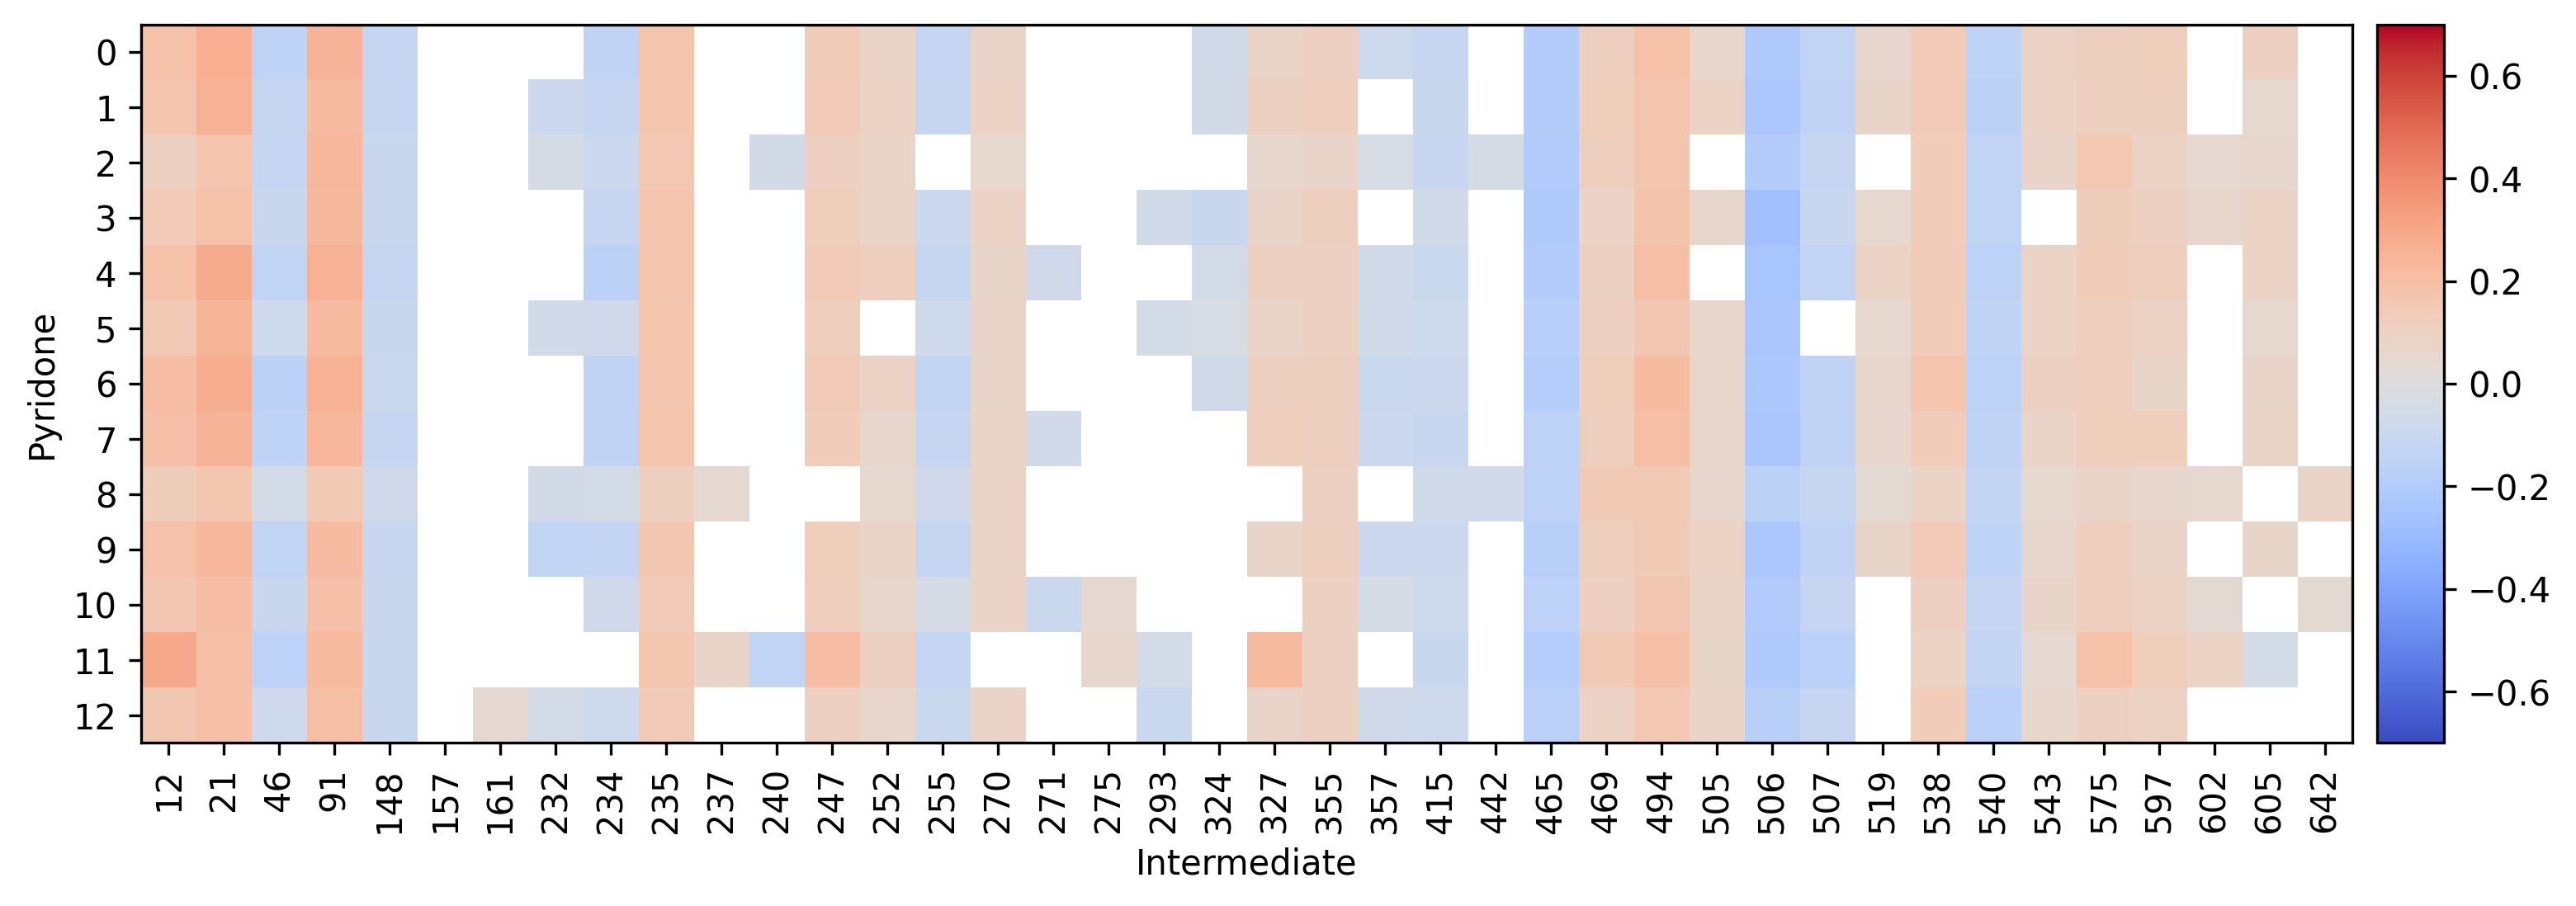

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 4), dpi=300)

im = ax.imshow(data, vmin=-0.7, vmax=0.7, cmap="coolwarm")

ax.set_xlabel("Intermediate")
ax.set_ylabel("Pyridone")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels(columns_feat, rotation=90)
ax.set_yticklabels(df_coefs_["pyridone_test"])

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file_write}_imshow.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [9]:
data_mean = df_coefs_[columns_feat].fill_null(0.0).mean().to_numpy().ravel()
data_std = df_coefs_[columns_feat].fill_null(0.0).std(ddof=1).to_numpy().ravel()
data_std = np.where(data_std == 0.0, np.nan, data_std)

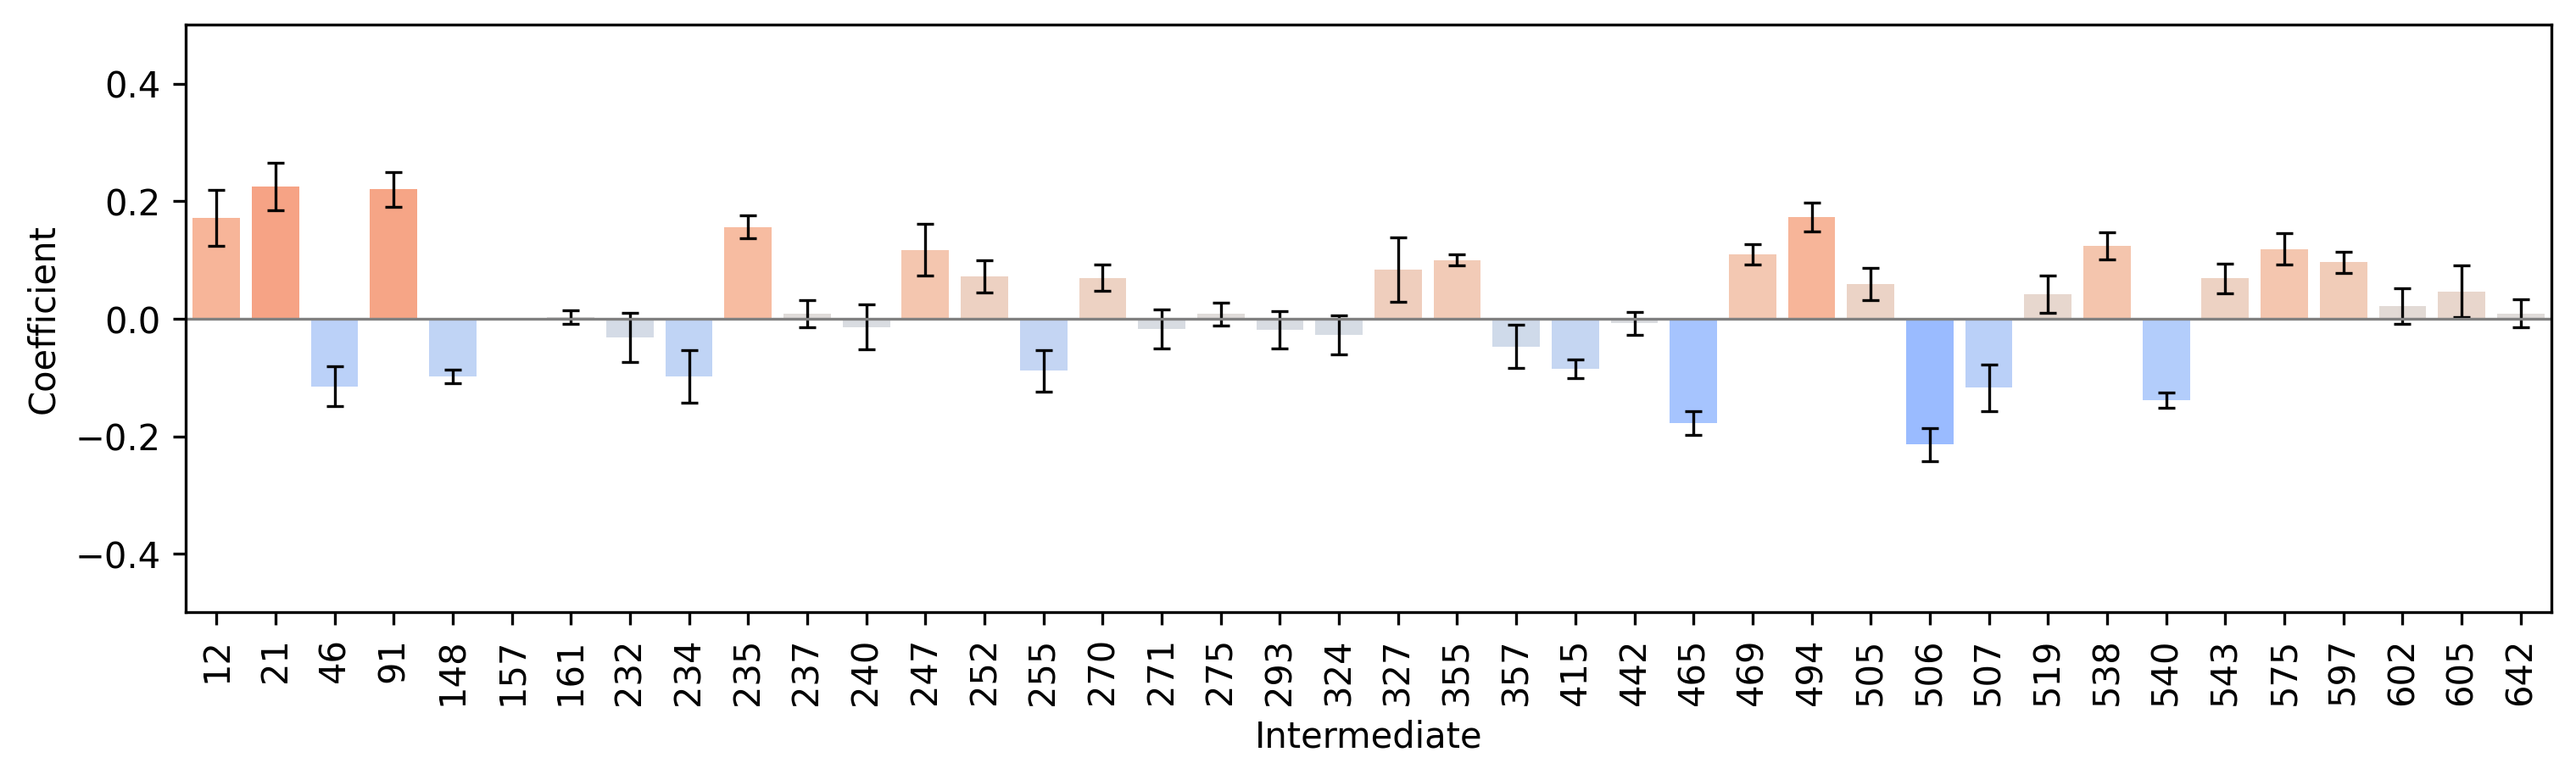

In [10]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-0.5, vmax=0.5)
colors = plt.cm.coolwarm(norm(data_mean))
error_kw = dict(elinewidth=0.8, capthick=0.8)
ax.bar(
    np.arange(len(data_mean)),
    data_mean,
    yerr=data_std,
    color=colors,
    capsize=2.5,
    error_kw=error_kw
)
ax.axhline(0, color="gray", linewidth=0.8)

ax.set_xlabel("Intermediate")
ax.set_ylabel("Coefficient")
ax.set_xticks(np.arange(len(data_mean)))
ax.set_xticklabels(columns_feat, rotation=90)
ax.margins(x=0.003)
ax.set_ylim(-0.5, 0.5)

plt.savefig(
    f"{file_write}_bar.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [11]:
data_mean

array([ 0.17208951,  0.22483139, -0.11484293,  0.22036353, -0.09845397,
        0.        ,  0.00314651, -0.03185505, -0.09807513,  0.15621765,
        0.00904274, -0.01407116,  0.11724039,  0.07253504, -0.08834521,
        0.06970967, -0.01719381,  0.00791801, -0.01874504, -0.02717105,
        0.08325883,  0.09989939, -0.04723721, -0.08539811, -0.00802655,
       -0.17810676,  0.10959651,  0.17272043,  0.05909387, -0.21436244,
       -0.11771034,  0.04185009,  0.12414836, -0.13929595,  0.06879466,
        0.11877152,  0.09594594,  0.02139432,  0.04674137,  0.00908464])

In [12]:
# Top 3 absolute values
# Int21, Int91, Int 506